# Analyse des résultats 

In [1]:
import pandas as pd

In [6]:
def merge_type(res):
    """
    Merge les résultats avec le dictionnaire pour ajouter les colonnes TYPE et TYPE2.
    entrée:
        res : df contenant les résultats avec une colonne 'SYMBOL' (les tickers).
    Return:
        df fusionné avec les colonnes 'TYPE' et 'TYPE2' ajoutées.
    """
    dict_bbg = pd.read_excel('Datasets/230210 Factor Set - Dictionnary (bbg only).xlsx')
    df_final = pd.merge(res, dict_bbg[['SYMBOL', 'TYPE', 'TYPE2']], on='SYMBOL', how='left')
    cols = ['SYMBOL', 'TYPE', 'TYPE2'] + [c for c in res.columns if c != 'SYMBOL']
    df_final['TYPE2'] = df_final['TYPE'].astype(str) + " - " + df_final['TYPE2'].astype(str)
    df_final = df_final[cols]
    return df_final

### Analyse AR(1)

In [3]:
res_ar = pd.read_csv('Resultats/resultats_all_tickers_AR(1).csv')

In [4]:
df_ar = merge_type(res_ar)
df_ar.head()

,SYMBOL,TYPE,TYPE2,MSE,OLS_R2,OLS_Intercept,OLS_Slope,OLS_P_Value_Intercept,P_Value_Slope
0,ADBF Index,Stock Market,Stock Market - Financials,0.000261,0.005777,0.000271,0.497567,0.350072,4.184202e-05
1,ADCM Index,Stock Market,Stock Market - Services,0.000528,0.006266,0.000580,0.388187,0.170883,3.824884e-05
2,ADCT Index,Stock Market,Stock Market - Industrials,0.000304,0.017216,0.000094,0.663209,0.753838,1.307078e-12
3,ADEG Index,Stock Market,Stock Market - Energy,0.000757,0.003857,-0.000040,0.456944,0.932014,1.244449e-03
4,ADHC Index,Stock Market,Stock Market - Health Care,0.000974,0.000828,-0.000178,0.178875,0.897489,5.209936e-01


In [9]:
def stats_par_type(df_final):
    df_final['is_significant'] = df_final['P_Value_Slope'] < 0.05

    stats_by_type = df_final.groupby('TYPE').agg({
        'P_Value_Slope': ['mean', 'std', 'min', 'max'], 
        'MSE': ['mean', 'std'],                         
        'OLS_R2': ['mean', 'median'],                   
        'OLS_Slope': 'mean',                            
        'is_significant': 'sum'                        
    }).rename(columns={'sum': 'count_significant'
                       }).sort_values(by=('P_Value_Slope', 'mean'))

    stats_by_type2 = df_final.groupby('TYPE2').agg({
        'MSE': 'mean',
        'OLS_R2': 'mean',
        'OLS_Slope': 'mean',
        'P_Value_Slope': 'mean'
    }).sort_values(by=('P_Value_Slope'))

    return stats_by_type, stats_by_type2

In [6]:
stats_type_ar, stats_type2_ar = stats_par_type(df_ar)

print("Stats par type:")
print(display(stats_type_ar.head()))

print("\nStats par type2 (secteurs plus précis):")
print(display(stats_type2_ar.head()))

significance_rate = stats_type_ar[('is_significant', 'count_significant')] / df_ar.groupby('TYPE').size()
print("\nRatio de significativité par type:")
print(significance_rate.sort_values(ascending=False))

Stats par type:


P_Value_Slope                                          \
                          mean       std            min            max   
TYPE                                                                     
Volatility       3.929919e-168  0.000000   0.000000e+00  2.750944e-167   
Real estate       1.502443e-02  0.045045   1.840678e-48   1.351445e-01   
Hedge Funds       6.740519e-02  0.116566   8.316800e-05   2.020040e-01   
Money Market      8.979813e-02  0.190402   0.000000e+00   8.443086e-01   
Corporate Bonds   1.286786e-01  0.285105  7.880041e-260   8.696342e-01   

                      MSE              OLS_R2           OLS_Slope  \
                     mean       std      mean    median      mean   
TYPE                                                                
Volatility       0.043291  0.033013  0.522683  0.362892  0.970629   
Real estate      0.000312  0.000194  0.017979  0.026585  0.551130   
Hedge Funds      0.000025  0.000007  0.002135  0.002237  0.163686   
Money Market     0.001133  0.003440  0.031444  0.007986  0.464747   
Corporate Bonds  0.000045  0.000110  0.030456  0.006321  0.461260   

                   is_significant  
                count_significant  
TYPE                               
Volatility                      7  
Real estate                     8  
Hedge Funds                     2  
Money Market                   40  
Corporate Bonds                21

None

Stats par type2 (secteurs plus précis):


,MSE,OLS_R2,OLS_Slope,P_Value_Slope
TYPE2,,,,
Volatility - -,0.043291,0.522683,0.970629,3.929919e-168
Equity Factors - Size,0.000131,0.009925,0.531553,1.968415e-04
Real estate - -,0.000312,0.017979,0.551130,1.502443e-02
Hedge Funds - -,0.000025,0.002135,0.163686,6.740519e-02
Money Market - Overnight,0.002460,0.029780,0.563992,7.131833e-02


None

Ratio de significativité par type:
TYPE
Volatility         1.000000
Real estate        0.888889
Corporate Bonds    0.807692
Money Market       0.727273
Hedge Funds        0.666667
Sovereign Bonds    0.615385
Equity Factors     0.585366
Stock Market       0.485938
Currency           0.453704
Commodity          0.405063
dtype: float64


## AR(1) (ret) 
juste pour voir si c'est les même

In [7]:
ret_ar_ret = pd.read_csv('Resultats/resultats_all_tickers_AR(1)_ret.csv')

df_ar_ret = merge_type(res_ar)
df_ar_ret.head()

stats_type_ar, stats_type2_ar = stats_par_type(df_ar_ret)

print("Stats par type:")
print(display(stats_type_ar.head()))

print("\nStats par type2 (secteurs plus précis):")
print(display(stats_type2_ar.head()))

significance_rate = stats_type_ar[('is_significant', 'count_significant')] / df_ar_ret.groupby('TYPE').size()
print("\nRatio de significativité par type:")
print(significance_rate.sort_values(ascending=False))

Stats par type:


P_Value_Slope                                          \
                          mean       std            min            max   
TYPE                                                                     
Volatility       3.929919e-168  0.000000   0.000000e+00  2.750944e-167   
Real estate       1.502443e-02  0.045045   1.840678e-48   1.351445e-01   
Hedge Funds       6.740519e-02  0.116566   8.316800e-05   2.020040e-01   
Money Market      8.979813e-02  0.190402   0.000000e+00   8.443086e-01   
Corporate Bonds   1.286786e-01  0.285105  7.880041e-260   8.696342e-01   

                      MSE              OLS_R2           OLS_Slope  \
                     mean       std      mean    median      mean   
TYPE                                                                
Volatility       0.043291  0.033013  0.522683  0.362892  0.970629   
Real estate      0.000312  0.000194  0.017979  0.026585  0.551130   
Hedge Funds      0.000025  0.000007  0.002135  0.002237  0.163686   
Money Market     0.001133  0.003440  0.031444  0.007986  0.464747   
Corporate Bonds  0.000045  0.000110  0.030456  0.006321  0.461260   

                   is_significant  
                count_significant  
TYPE                               
Volatility                      7  
Real estate                     8  
Hedge Funds                     2  
Money Market                   40  
Corporate Bonds                21

None

Stats par type2 (secteurs plus précis):


,MSE,OLS_R2,OLS_Slope,P_Value_Slope
TYPE2,,,,
Volatility - -,0.043291,0.522683,0.970629,3.929919e-168
Equity Factors - Size,0.000131,0.009925,0.531553,1.968415e-04
Real estate - -,0.000312,0.017979,0.551130,1.502443e-02
Hedge Funds - -,0.000025,0.002135,0.163686,6.740519e-02
Money Market - Overnight,0.002460,0.029780,0.563992,7.131833e-02


None

Ratio de significativité par type:
TYPE
Volatility         1.000000
Real estate        0.888889
Corporate Bonds    0.807692
Money Market       0.727273
Hedge Funds        0.666667
Sovereign Bonds    0.615385
Equity Factors     0.585366
Stock Market       0.485938
Currency           0.453704
Commodity          0.405063
dtype: float64


## Tableau et figures pour le papier

GLOBAL LEADERBOARD
                               MSE    OLS_R2  OLS_Slope  Significance_ratio
Model                                                                      
LGBM_opti                 0.000453  0.041454   0.681846            0.991304
AR(2)                     0.002145  0.016764   0.354294            0.747408
AR(5)                     0.002257  0.014416   0.243439            0.714420
AR(10)                    0.002496  0.012101   0.159213            0.629595
GRU_Stacked_seq8          0.001276  0.005587   0.137990            0.555556
AR(1)                     0.002142  0.012783   0.232658            0.476909
SARIMA(1,1,1)(0,1,1)_21  13.847974  0.000985   0.000582            0.138837
ARMA(5,5)                 0.009728  0.005097  -0.017468            0.137899
SARIMA(1,1,1)(0,1,1)_5   80.403305  0.000750   0.000129            0.136961
MA(10)                    0.005383  0.005355  -0.010782            0.133208
ARIMA(1,1,1)              0.005082  0.005661   0.016455            0.

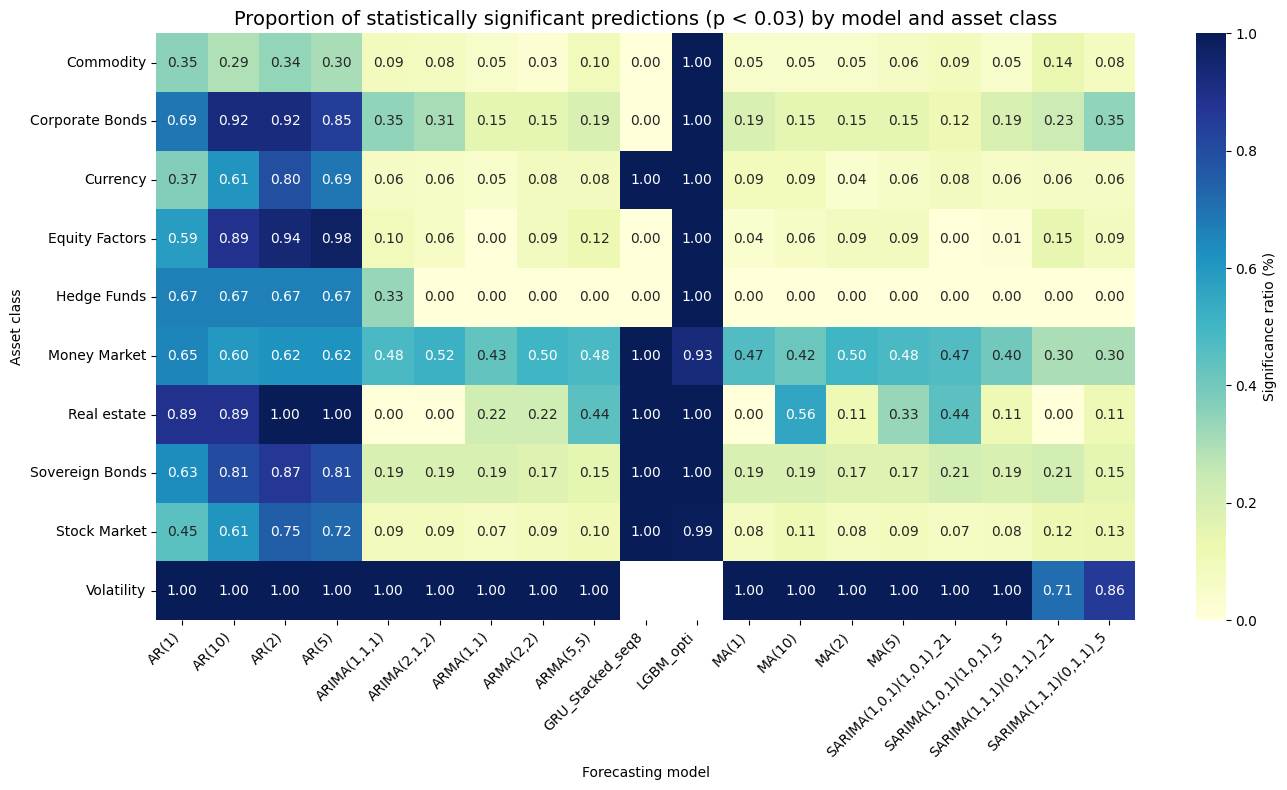

In [11]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

def load_and_merge_all_results(results_dir, dict_path):
    """
    Charge tous les CSV de résultats, extrait le nom du modèle, 
    et fusionne avec le dictionnaire des classes d'actifs.
    """
    dict_bbg = pd.read_excel(dict_path)
    
    all_data = []
    
    for file in os.listdir(results_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(results_dir, file)
            df_temp = pd.read_csv(file_path)
            
            model_name = file.replace('resultats_all_tickers_', '') \
                             .replace('resultats_test_tickers_', '') \
                             .replace('_all_tickers', '') \
                             .replace('.csv', '') \
                             .replace('resultats_', '')
            
            df_temp['Model'] = model_name
            all_data.append(df_temp)
            
    df_all = pd.concat(all_data, ignore_index=True)
    df_final = pd.merge(df_all, dict_bbg[['SYMBOL', 'TYPE', 'TYPE2']], on='SYMBOL', how='left')
    
    df_final['is_significant'] = df_final['P_Value_Slope'] < 0.03
    
    return df_final

def generate_paper_tables(df_final):
    print("GLOBAL LEADERBOARD")
    global_summary = df_final.groupby('Model').agg({
        'MSE': 'mean',
        'OLS_R2': 'mean',
        'OLS_Slope': 'mean',
        'is_significant': 'mean'
    }).rename(columns={'is_significant': 'Significance_ratio'}).sort_values(by='Significance_ratio', ascending=False)
    
    print(global_summary)
    print("\n")
    
    print("SIGNIFICANCE RATIO BY ASSET CLASS (HEATMAP DATA)")
    pivot_sig = df_final.pivot_table(
        index='TYPE', 
        columns='Model', 
        values='is_significant', 
        aggfunc='mean'
    )
    print(pivot_sig)
    print("\n")
    
    print("R2 MEAN BY ASSET CLASS")
    pivot_r2 = df_final.pivot_table(
        index='TYPE', 
        columns='Model', 
        values='OLS_R2', 
        aggfunc='mean'
    )
    print(pivot_r2)
    
    return global_summary, pivot_sig, pivot_r2

RESULTS_DIR = 'Resultats'
DICT_PATH = 'Datasets/230210 Factor Set - Dictionnary (bbg only).xlsx'

df_master = load_and_merge_all_results(RESULTS_DIR, DICT_PATH)
global_summary, pivot_sig, pivot_r2 = generate_paper_tables(df_master)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_sig, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Significance ratio (%)'})
plt.title("Proportion of statistically significant predictions (p < 0.03) by model and asset class", fontsize=14)
plt.ylabel("Asset class")
plt.xlabel("Forecasting model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
res_elastic_net = pd.read_csv('Resultats/resultats_all_tickers_ElasticNet_alpha1e3_l1r02_scaled.csv')
res_elastic_net = res_elastic_net.rename(columns={'name': 'SYMBOL'})

df_elastic_net = merge_type(res_elastic_net)
df_elastic_net.head()

,SYMBOL,TYPE,TYPE2,MSE,OLS_R2,OLS_Intercept,OLS_Slope,OLS_P_Value_Intercept,P_Value_Slope
0,ADBF Index,Stock Market,Stock Market - Financials,0.000644,0.031048,0.001203,0.121310,0.000038,2.979237e-21
1,ADCM Index,Stock Market,Stock Market - Services,0.000791,0.070376,0.001364,0.236631,0.000852,7.929166e-44
2,ADCT Index,Stock Market,Stock Market - Industrials,0.000356,0.078859,0.000812,0.310084,0.006551,1.561125e-52
3,ADEG Index,Stock Market,Stock Market - Energy,0.000978,0.067379,0.000680,0.239087,0.142009,2.131336e-42
4,ADHC Index,Stock Market,Stock Market - Health Care,0.001207,0.118604,0.003425,0.374352,0.013483,4.609588e-15


In [11]:
stats_type_elastic_net, stats_type2_elastic_net = stats_par_type(df_elastic_net)

print("Stats par type:")
print(display(stats_type_elastic_net.head()))

print("\nStats par type2 (secteurs plus précis):")
print(display(stats_type2_elastic_net.head()))

significance_rate = stats_type_elastic_net[('is_significant', 'count_significant')] / df_ar.groupby('TYPE').size()
print("\nRatio de significativité par type:")
print(significance_rate.sort_values(ascending=False))

Stats par type:


P_Value_Slope                                             \
                         mean           std            min           max   
TYPE                                                                       
Hedge Funds      1.806869e-37  3.129588e-37  5.824712e-113  5.420606e-37   
Equity Factors   7.147593e-21  6.472411e-20  2.088478e-147  5.861018e-19   
Sovereign Bonds  6.337136e-07  4.430613e-06  8.691395e-146  3.196523e-05   
Corporate Bonds  1.522971e-06  6.651395e-06  1.636625e-177  3.362544e-05   
Commodity        2.424449e-03  2.125357e-02  1.047147e-113  1.865016e-01   

                      MSE              OLS_R2           OLS_Slope  \
                     mean       std      mean    median      mean   
TYPE                                                                
Hedge Funds      0.000023  0.000007  0.064823  0.062706  0.510235   
Equity Factors   0.000192  0.000097  0.070585  0.068699  0.276252   
Sovereign Bonds  0.000134  0.000762  0.046104  0.047347  0.490010   
Corporate Bonds  0.000062  0.000217  0.051475  0.050420  0.480472   
Commodity        0.000634  0.000549  0.064579  0.062920  0.270607   

                   is_significant  
                count_significant  
TYPE                               
Hedge Funds                     3  
Equity Factors                 82  
Sovereign Bonds                52  
Corporate Bonds                26  
Commodity                      76

None

Stats par type2 (secteurs plus précis):


,MSE,OLS_R2,OLS_Slope,P_Value_Slope
TYPE2,,,,
Equity Factors - Size,0.000173,0.072437,0.288154,3.513533e-102
Commodity - All,0.000247,0.067379,0.272144,1.067567e-70
Currency - Strategy,0.000028,0.063802,0.448623,4.749138e-69
Commodity - Precious Stones and Metals,0.000434,0.067273,0.283092,7.699377e-57
Commodity - Grains,0.000499,0.060327,0.243771,1.412399e-51


None

Ratio de significativité par type:
TYPE
Corporate Bonds    1.000000
Equity Factors     1.000000
Hedge Funds        1.000000
Real estate        1.000000
Sovereign Bonds    1.000000
Stock Market       0.992051
Currency           0.990476
Commodity          0.987013
Money Market       0.925926
dtype: float64


GLOBAL LEADERBOARD
                                       MSE    OLS_R2  OLS_Slope  \
Model                                                             
RF_n_estimators_100_max_depth_5   0.000314  0.039103   0.393463   
XGB_n500_lr001_d4                 0.000306  0.053804   0.439719   
RF_n_estimators_100_max_depth_3   0.000309  0.033666   0.405925   
ElasticNet_alpha1e3_l1r02_scaled  0.000668  0.064470   0.296574   
Ridge_alpha001_scaled             0.000926  0.063542   0.191127   
RF_n_estimators_1_max_depth_1     0.000380  0.008848   0.151040   
RF_n_estimators_10_max_depth_1    0.000379  0.008756   0.150331   

                                  Significance_ratio  
Model                                                 
RF_n_estimators_100_max_depth_5             0.994203  
XGB_n500_lr001_d4                           0.993237  
RF_n_estimators_100_max_depth_3             0.991254  
ElasticNet_alpha1e3_l1r02_scaled            0.988406  
Ridge_alpha001_scaled                       0.9

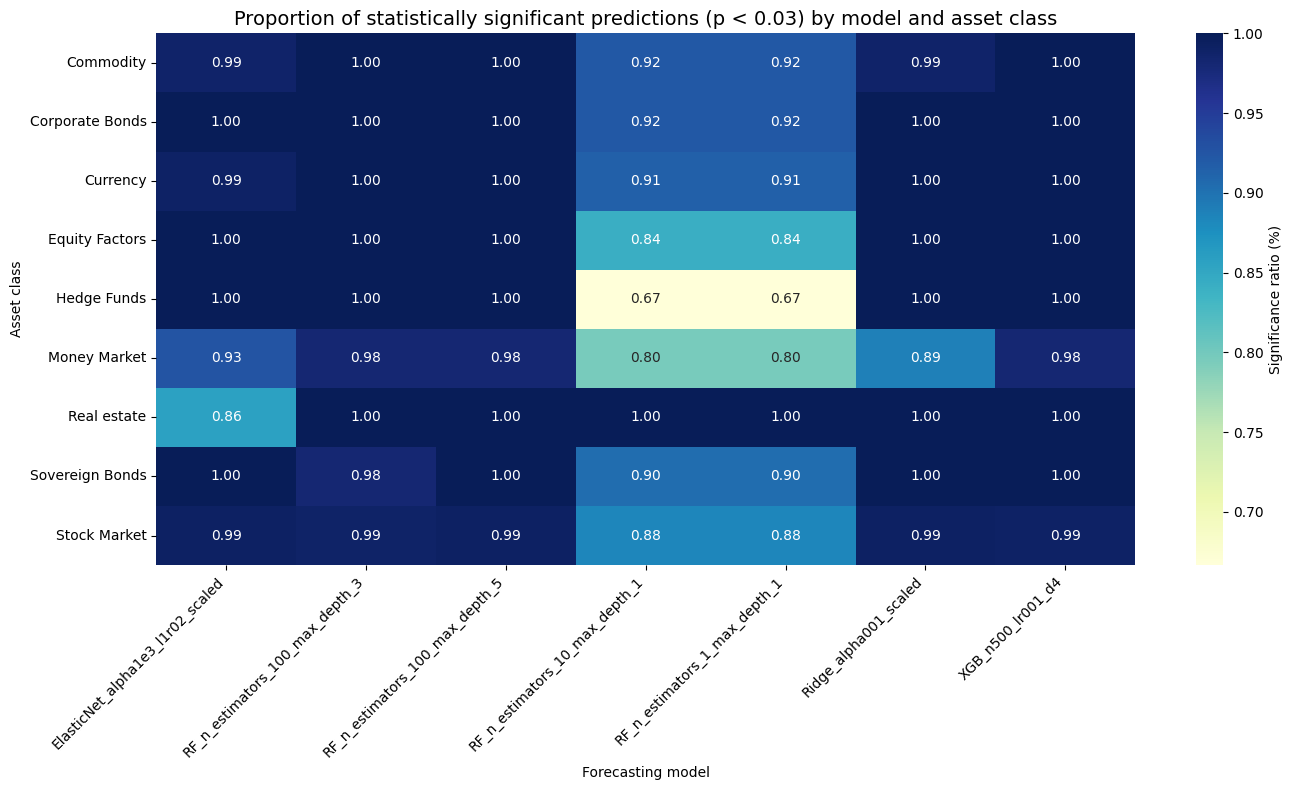

In [15]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

def load_and_merge_all_results(results_dir, dict_path):
    """
    Charge tous les CSV de résultats, extrait le nom du modèle, 
    et fusionne avec le dictionnaire des classes d'actifs.
    """
    dict_bbg = pd.read_excel(dict_path)
    
    all_data = []
    
    for file in os.listdir(results_dir):
        if file.endswith('.csv'):
            file_path = os.path.join(results_dir, file)
            df_temp = pd.read_csv(file_path)
            
            model_name = file.replace('resultats_all_tickers_', '') \
                             .replace('resultats_test_tickers_', '') \
                             .replace('_all_tickers', '') \
                             .replace('.csv', '') \
                             .replace('resultats_', '')
            
            df_temp['Model'] = model_name
            all_data.append(df_temp)
            
    df_all = pd.concat(all_data, ignore_index=True)
    df_final = pd.merge(df_all, dict_bbg[['SYMBOL', 'TYPE', 'TYPE2']], on='SYMBOL', how='left')
    
    df_final['is_significant'] = df_final['P_Value_Slope'] < 0.03
    
    return df_final

def generate_paper_tables(df_final):
    print("GLOBAL LEADERBOARD")
    global_summary = df_final.groupby('Model').agg({
        'MSE': 'mean',
        'OLS_R2': 'mean',
        'OLS_Slope': 'mean',
        'is_significant': 'mean'
    }).rename(columns={'is_significant': 'Significance_ratio'}).sort_values(by='Significance_ratio', ascending=False)
    
    print(global_summary)
    print("\n")
    
    print("SIGNIFICANCE RATIO BY ASSET CLASS (HEATMAP DATA)")
    pivot_sig = df_final.pivot_table(
        index='TYPE', 
        columns='Model', 
        values='is_significant', 
        aggfunc='mean'
    )
    print(pivot_sig)
    print("\n")
    
    print("R2 MEAN BY ASSET CLASS")
    pivot_r2 = df_final.pivot_table(
        index='TYPE', 
        columns='Model', 
        values='OLS_R2', 
        aggfunc='mean'
    )
    print(pivot_r2)
    
    return global_summary, pivot_sig, pivot_r2

RESULTS_DIR = 'Resultats'
DICT_PATH = 'Datasets/230210 Factor Set - Dictionnary (bbg only).xlsx'

df_master = load_and_merge_all_results(RESULTS_DIR, DICT_PATH)
global_summary, pivot_sig, pivot_r2 = generate_paper_tables(df_master)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_sig, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Significance ratio (%)'})
plt.title("Proportion of statistically significant predictions (p < 0.03) by model and asset class", fontsize=14)
plt.ylabel("Asset class")
plt.xlabel("Forecasting model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()